# Preprocessing of Data sources

This notebook shows how to gather the data from various data sources required for the IWU estimates and also performs pre-processing steps like regridding the various datasets to the same spatial and temporal dimensions and convert the units of the variables to the requested ones.

**Output**: A unified pre-processed dataset ready for calibration and predictions 

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

First lets load the shapefile providing us with the region that we will create our dataset for development and testing purposes.

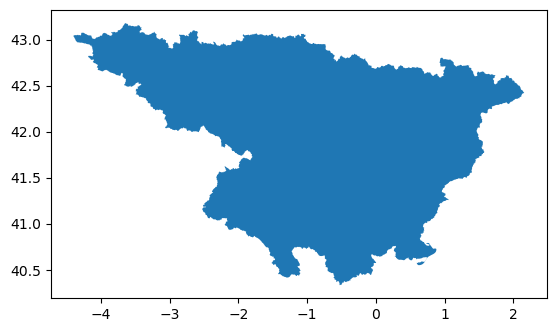

In [2]:
gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()

In [3]:
print(gdf.crs) 

EPSG:4326


In [4]:
# To be used for all the data sources

# bbox = [-31, 27, 40, 81] # Europe
bbox = [-5, 40, 3, 44] # Ebro Basin
time_range = ("2020-01-01", "2021-12-31")

In [5]:
### Land Cover

store_lccs=new_data_store("s3", root="deep-esdl-public")
mlds_lc = store_lccs.open_data("LC-1x2025x2025-2.0.0.levels")
lc = mlds_lc.base_dataset

In [7]:
tds = new_data_store("file", root="input2years")

In [9]:
lc = lc.sel(time="2020-01-01")
lc

<xarray.Dataset> Size: 101GB
Dimensions:              (lat: 64800, lon: 129600, bounds: 2)
Coordinates:
  * lat                  (lat) float64 518kB 90.0 90.0 89.99 ... -90.0 -90.0
  * lon                  (lon) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0
    time                 datetime64[ns] 8B 2020-01-01
Dimensions without coordinates: bounds
Data variables:
    change_count         (lat, lon) uint8 8GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    crs                  int32 4B ...
    current_pixel_state  (lat, lon) float32 34GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    lat_bounds           (lat, bounds) float64 1MB dask.array<chunksize=(2025, 2), meta=np.ndarray>
    lccs_class           (lat, lon) uint8 8GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    lon_bounds           (lon, bounds) float64 2MB dask.array<chunksize=(2025, 2), meta=np.ndarray>
    observation_count    (lat, lon) uint16 17GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    processed_flag       (lat, lon) float32 34GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    time_bounds          (bounds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

In [11]:
tds.write_data(lc, "landcover2020global.zarr")

'landcover2020global.zarr'

In [ ]:
lc_

In [ ]:

subset = ds.sel(
    lon=slice(min_lon, max_lon),
    lat=slice(max_lat, min_lat)  # note: lat often decreases from north to south
)

CPU times: user 98.8 ms, sys: 46.9 ms, total: 146 ms
Wall time: 8.51 s


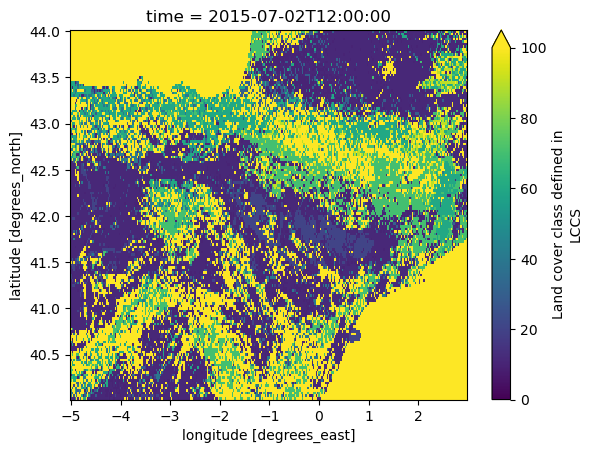

In [7]:
%%time
downsampled_cube = lc_cci.lccs_class.isel(
    lat=slice(None, None, 10),
    lon=slice(None, None, 10),
)
downsampled_cube.plot(vmin=0, vmax=100)

In [15]:
def split_date_range(start_date, end_date, num_days=30):
    if isinstance(start_date, str):
        start_date = datetime.strptime(start_date, "%Y-%m-%d")
    if isinstance(end_date, str):
        end_date = datetime.strptime(end_date, "%Y-%m-%d")
    
    result = []
    current = start_date
    
    while current <= end_date:
        chunk_end = min(current + timedelta(days=num_days - 1), end_date)
        result.append((current.strftime("%Y-%m-%d"), chunk_end.strftime("%Y-%m-%d")))
        current = chunk_end + timedelta(days=1)
    
    return result

In [27]:
time_ranges = split_date_range(time_range[0], time_range[1], 10)
time_ranges, len(time_ranges)

([('2020-01-01', '2020-01-10'),
  ('2020-01-11', '2020-01-20'),
  ('2020-01-21', '2020-01-30'),
  ('2020-01-31', '2020-02-09'),
  ('2020-02-10', '2020-02-19'),
  ('2020-02-20', '2020-02-29'),
  ('2020-03-01', '2020-03-10'),
  ('2020-03-11', '2020-03-20'),
  ('2020-03-21', '2020-03-30'),
  ('2020-03-31', '2020-04-09'),
  ('2020-04-10', '2020-04-19'),
  ('2020-04-20', '2020-04-29'),
  ('2020-04-30', '2020-05-09'),
  ('2020-05-10', '2020-05-19'),
  ('2020-05-20', '2020-05-29'),
  ('2020-05-30', '2020-06-08'),
  ('2020-06-09', '2020-06-18'),
  ('2020-06-19', '2020-06-28'),
  ('2020-06-29', '2020-07-08'),
  ('2020-07-09', '2020-07-18'),
  ('2020-07-19', '2020-07-28'),
  ('2020-07-29', '2020-08-07'),
  ('2020-08-08', '2020-08-17'),
  ('2020-08-18', '2020-08-27'),
  ('2020-08-28', '2020-09-06'),
  ('2020-09-07', '2020-09-16'),
  ('2020-09-17', '2020-09-26'),
  ('2020-09-27', '2020-10-06'),
  ('2020-10-07', '2020-10-16'),
  ('2020-10-17', '2020-10-26'),
  ('2020-10-27', '2020-11-05'),
  ('2020

In [34]:
new_time_range = split_date_range("2020-12-16", "2021-12-31", 5)
new_time_range

[('2020-12-16', '2020-12-20'),
 ('2020-12-21', '2020-12-25'),
 ('2020-12-26', '2020-12-30'),
 ('2020-12-31', '2021-01-04'),
 ('2021-01-05', '2021-01-09'),
 ('2021-01-10', '2021-01-14'),
 ('2021-01-15', '2021-01-19'),
 ('2021-01-20', '2021-01-24'),
 ('2021-01-25', '2021-01-29'),
 ('2021-01-30', '2021-02-03'),
 ('2021-02-04', '2021-02-08'),
 ('2021-02-09', '2021-02-13'),
 ('2021-02-14', '2021-02-18'),
 ('2021-02-19', '2021-02-23'),
 ('2021-02-24', '2021-02-28'),
 ('2021-03-01', '2021-03-05'),
 ('2021-03-06', '2021-03-10'),
 ('2021-03-11', '2021-03-15'),
 ('2021-03-16', '2021-03-20'),
 ('2021-03-21', '2021-03-25'),
 ('2021-03-26', '2021-03-30'),
 ('2021-03-31', '2021-04-04'),
 ('2021-04-05', '2021-04-09'),
 ('2021-04-10', '2021-04-14'),
 ('2021-04-15', '2021-04-19'),
 ('2021-04-20', '2021-04-24'),
 ('2021-04-25', '2021-04-29'),
 ('2021-04-30', '2021-05-04'),
 ('2021-05-05', '2021-05-09'),
 ('2021-05-10', '2021-05-14'),
 ('2021-05-15', '2021-05-19'),
 ('2021-05-20', '2021-05-24'),
 ('2021-

In [12]:
era_store = new_data_store("file", root="era5")

In [30]:
from tqdm.notebook import tqdm

In [35]:
%%time
# ERA5

cds_store = new_data_store("cds", normalize_names=True)

data_id = 'reanalysis-era5-land'
variables = ("soil_temperature_level_1", "potential_evaporation", "total_precipitation", "snowfall")
spatial_res = 0.1

for _time_range in tqdm(new_time_range):
    cds_cube = cds_store.open_data(
        data_id,
        cds_store.get_data_opener_ids()[0],
        variable_names=variables,
        bbox=bbox,
        spatial_res=spatial_res,
        time_range=_time_range
    )
    era_store.write_data(cds_cube, f"era5-{_time_range[0].replace("-", "_")}-{_time_range[1].replace("-", "_")}.zarr", replace=True)

  0%|          | 0/77 [00:00<?, ?it/s]

xcube-cds version 1.1.0.dev0
2025-08-25 17:32:13,102 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-25 17:32:13,274 INFO Request ID is b40b3467-f4ad-4696-ab7a-2518db5ae8b1
INFO:ecmwf.datastores.legacy_client:Request ID is b40b3467-f4ad-4696-ab7a-2518db5ae8b1
2025-08-25 17:32:13,345 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-25 17:32:21,768 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-08-25 17:33:28,864 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


dea7e486db9a149b6d5959761a13fe68.zip:   0%|          | 0.00/2.20M [00:00<?, ?B/s]

xcube-cds version 1.1.0.dev0
2025-08-25 17:33:29,983 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-25 17:33:30,178 INFO Request ID is c996cbe1-6b26-44c3-9b82-460ad4166d0d
INFO:ecmwf.datastores.legacy_client:Request ID is c996cbe1-6b26-44c3-9b82-460ad4166d0d
2025-08-25 17:33:30,240 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-25 17:33:38,853 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-08-25 17:34:45,946 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


bf90e577efd4aad3b637dc7a21df085d.zip:   0%|          | 0.00/2.35M [00:00<?, ?B/s]

...

xcube-cds version 1.1.0.dev0
2025-08-26 11:34:10,144 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-26 11:34:10,288 INFO Request ID is 8141f134-9741-4a26-9700-2e31b00dfdf5
INFO:ecmwf.datastores.legacy_client:Request ID is 8141f134-9741-4a26-9700-2e31b00dfdf5
2025-08-26 11:34:10,341 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-26 11:34:24,098 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-08-26 11:36:04,985 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


19cb3a3c209e1e6146cecf9b97f6c87b.zip:   0%|          | 0.00/2.20M [00:00<?, ?B/s]

xcube-cds version 1.1.0.dev0
2025-08-26 11:36:06,091 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-26 11:36:06,522 INFO Request ID is 38715745-89f1-4cf7-8232-1c21b0b2bfd4
INFO:ecmwf.datastores.legacy_client:Request ID is 38715745-89f1-4cf7-8232-1c21b0b2bfd4
2025-08-26 11:36:06,619 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-26 11:36:27,886 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


914a90019651a956d5a4dbd93a3dd4cc.zip:   0%|          | 0.00/72.1k [00:00<?, ?B/s]

CPU times: user 10.9 s, sys: 2.21 s, total: 13.1 s
Wall time: 18h 4min 15s


In [13]:
data_ids = era_store.list_data_ids()

In [14]:
%%time
from zappend.api import zappend

final_data_id = "era5.zarr"
config = {
    "target_dir": "input2years/era5.zarr",
    "force_new": True,
    "logging": True,
    "excluded_variables": ["expver", "number"]
}
zappend((f'era5/{data_id}' for data_id in sorted(data_ids)), config=config)

2025-08-28 14:48:33,746 WARNING Setting 'force_new' is enabled. This will permanently delete existing targets (no rollback).
2025-08-28 14:48:33,749 WARNING Permanently deleting input2years/era5.zarr
2025-08-28 14:48:33,761 INFO Opening slice dataset from era5/era5-2020_01_01-2020_01_10.zarr
INFO:zappend:Opening slice dataset from era5/era5-2020_01_01-2020_01_10.zarr
2025-08-28 14:48:33,768 INFO Creating target dataset input2years/era5.zarr
INFO:zappend:Creating target dataset input2years/era5.zarr
/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/zappend/processor.py:151: FutureWarning: zarr_version is deprecated, use zarr_format
  target_ds.to_zarr(
2025-08-28 14:48:33,806 INFO Transaction completed.
INFO:zappend:Transaction completed.
2025-08-28 14:48:33,807 INFO Slice dataset era5/era5-2020_01_01-2020_01_10.zarr closed
INFO:zappend:Slice dataset era5/era5-2020_01_01-2020_01_10.zarr closed
2025-08-28 14:48:33,814 INFO Opening slice dataset

CPU times: user 10 s, sys: 3.19 s, total: 13.2 s
Wall time: 9.9 s


112

In [16]:
tds.list_data_ids()

['clms_zappend.zarr', 'era5.zarr']

In [17]:
cds_cube = tds.open_data("era5.zarr")

In [18]:
cds_cube

<xarray.Dataset> Size: 897MB
Dimensions:  (time: 17521, lat: 40, lon: 80)
Coordinates:
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
  * time     (time) datetime64[ns] 140kB 2020-01-01 ... 2021-12-31
Data variables:
    pev      (time, lat, lon) float32 224MB dask.array<chunksize=(240, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 224MB dask.array<chunksize=(240, 40, 80), meta=np.ndarray>
    stl1     (time, lat, lon) float32 224MB dask.array<chunksize=(240, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 224MB dask.array<chunksize=(240, 40, 80), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-25T12:46 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

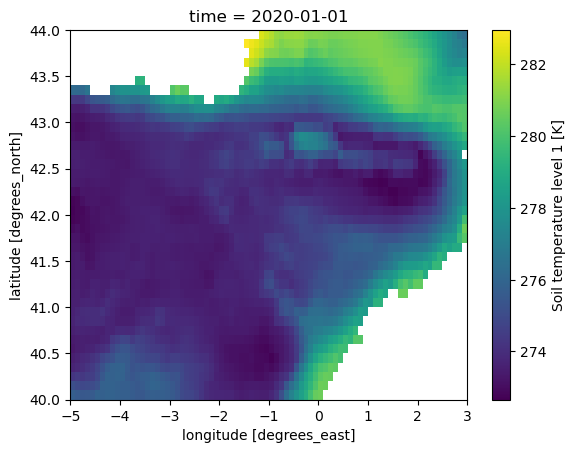

In [19]:
cds_cube.isel(time=0).stl1.plot()

In [10]:
# time_range = ('2020-01-01', '2020-01-20')

In [9]:
%%time
# CLMS

json_file_path = "credentials.json"
with open(json_file_path, "r") as j:
    credentials = json.loads(j.read())

clms_data_store = new_data_store("clms", credentials=credentials)

clms_data = clms_data_store.open_data("daily-surface-soil-moisture-v1.0", time_range=time_range)
clms_data

INFO:xcube.clms:Fetching datasets metadata from https://land.copernicus.eu/api
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=25&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=50&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=75&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=100&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=125&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=150&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search

CPU times: user 2.44 s, sys: 466 ms, total: 2.91 s
Wall time: 40.8 s


<xarray.Dataset> Size: 7GB
Dimensions:    (time: 31, lat: 4144, lon: 6832)
Coordinates:
  * lat        (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon        (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    crs        (time) |S1 31B b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    ssm        (time, lat, lon) float32 4GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
    ssm_noise  (time, lat, lon) float32 4GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [ ]:
clms_ssm_only = clms_data.drop_vars("ssm_noise") 

In [ ]:
import dask
dask.config.set(scheduler="threads", num_workers=2)

In [ ]:
%%time
tds.write_data(clms_ssm_only, f"clms.zarr")

In [ ]:
# %%time
# from zappend.api import zappend

# config = {
#     "target_dir": "input2years/clms_zappend.zarr",
#     "force_new": True,
#     "logging": True,
#     "slice_engine": "h5netcdf",
# }
# zappend([clms_ssm_only], config=config)

In [37]:
clms_data = tds.open_data("clms.zarr")

In [38]:
%%time
clms_data = clms_data.sel(lat=slice(44, 40), lon=slice(-5, 3))

CPU times: user 3.83 ms, sys: 8.98 ms, total: 12.8 ms
Wall time: 82.4 ms


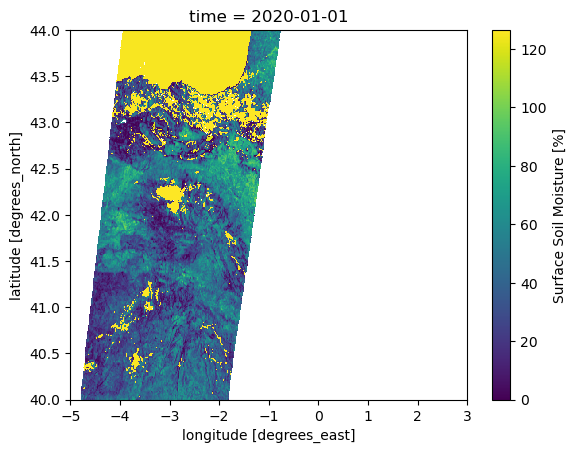

In [39]:
# clms_data.isel(time=0, lat=slice(None, None, 50), lon=slice(None, None, 50)).ssm.plot()
clms_data.isel(time=0).ssm.plot()

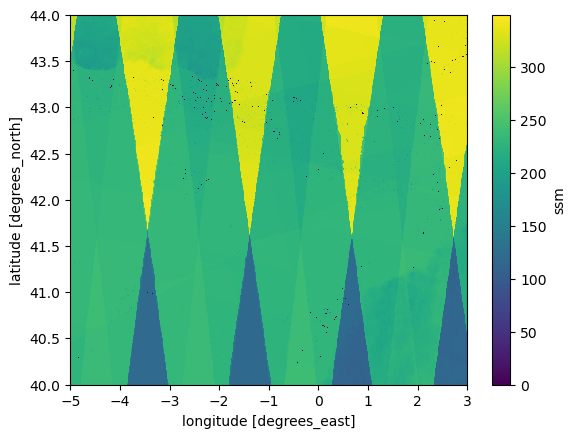

In [40]:
clms_data.ssm.count(dim='time').plot()

## Preprocessing

### Soil Moisture (CLMS) - Interpolation

In [41]:
def swicomp_nan(in_data, in_jd, ctime=2):
    filtered = np.empty(len(in_data))
    gain = 1
    filtered.fill(np.nan)

    ID = np.where(~np.isnan(in_data))
    if len(ID[0]) == 0:
        return filtered

    D = in_jd[ID]
    SWI = in_data[ID].copy()
    tdiff = np.diff(D)

    for i in range(2, SWI.size):
        gain = gain / (gain + np.exp(- tdiff[i - 1] / ctime))
        SWI[i] = SWI[i - 1] + gain * (SWI[i] - SWI[i-1])

    filtered[ID] = SWI
    return filtered

In [42]:
julian_dates = xr.DataArray(
    pd.to_datetime(clms_data.time.values).to_julian_date().values,
    dims='time',
    coords={'time': clms_data.time}
)
julian_dates

<xarray.DataArray (time: 729)> Size: 6kB
array([2458849.5, 2458850.5, 2458851.5, 2458852.5, 2458853.5, 2458854.5,
       2458855.5, 2458856.5, 2458857.5, 2458858.5, 2458859.5, 2458860.5,
       2458861.5, 2458862.5, 2458863.5, 2458864.5, 2458865.5, 2458866.5,
       2458867.5, 2458868.5, 2458869.5, 2458870.5, 2458871.5, 2458872.5,
       2458873.5, 2458874.5, 2458875.5, 2458876.5, 2458877.5, 2458878.5,
       2458879.5, 2458880.5, 2458881.5, 2458882.5, 2458883.5, 2458884.5,
       2458885.5, 2458886.5, 2458887.5, 2458888.5, 2458889.5, 2458890.5,
       2458891.5, 2458892.5, 2458893.5, 2458894.5, 2458895.5, 2458896.5,
       2458897.5, 2458898.5, 2458899.5, 2458900.5, 2458901.5, 2458902.5,
       2458903.5, 2458904.5, 2458905.5, 2458906.5, 2458907.5, 2458908.5,
       2458909.5, 2458910.5, 2458911.5, 2458912.5, 2458913.5, 2458914.5,
       2458915.5, 2458916.5, 2458917.5, 2458918.5, 2458919.5, 2458920.5,
       2458921.5, 2458922.5, 2458923.5, 2458924.5, 2458925.5, 2458926.5,
       2458927.5, 2458928.5, 2458929.5, 2458930.5, 2458931.5, 2458932.5,
       2458933.5, 2458934.5, 2458935.5, 2458936.5, 2458937.5, 2458938.5,
       2458939.5, 2458940.5, 2458941.5, 2458942.5, 2458943.5, 2458944.5,
       2458945.5, 2458946.5, 2458947.5, 2458948.5, 2458949.5, 2458950.5,
       2458951.5, 2458952.5, 2458953.5, 2458954.5, 2458955.5, 2458956.5,
       2458957.5, 2458958.5, 2458959.5, 2458960.5, 2458961.5, 2458962.5,
       2458963.5, 2458964.5, 2458965.5, 2458966.5, 2458967.5, 2458968.5,
...
       2459463.5, 2459464.5, 2459465.5, 2459466.5, 2459467.5, 2459468.5,
       2459469.5, 2459470.5, 2459471.5, 2459472.5, 2459473.5, 2459474.5,
       2459475.5, 2459476.5, 2459477.5, 2459478.5, 2459479.5, 2459480.5,
       2459481.5, 2459482.5, 2459483.5, 2459484.5, 2459485.5, 2459486.5,
       2459487.5, 2459488.5, 2459489.5, 2459490.5, 2459491.5, 2459492.5,
       2459493.5, 2459494.5, 2459495.5, 2459496.5, 2459497.5, 2459498.5,
       2459499.5, 2459500.5, 2459501.5, 2459502.5, 2459503.5, 2459504.5,
       2459505.5, 2459506.5, 2459507.5, 2459508.5, 2459509.5, 2459510.5,
       2459511.5, 2459512.5, 2459513.5, 2459514.5, 2459515.5, 2459516.5,
       2459517.5, 2459518.5, 2459519.5, 2459520.5, 2459521.5, 2459522.5,
       2459523.5, 2459524.5, 2459525.5, 2459526.5, 2459527.5, 2459528.5,
       2459529.5, 2459530.5, 2459531.5, 2459532.5, 2459533.5, 2459534.5,
       2459535.5, 2459536.5, 2459537.5, 2459538.5, 2459539.5, 2459540.5,
       2459541.5, 2459542.5, 2459543.5, 2459544.5, 2459545.5, 2459546.5,
       2459547.5, 2459548.5, 2459549.5, 2459550.5, 2459551.5, 2459552.5,
       2459553.5, 2459554.5, 2459555.5, 2459556.5, 2459557.5, 2459558.5,
       2459559.5, 2459560.5, 2459561.5, 2459562.5, 2459563.5, 2459564.5,
       2459565.5, 2459566.5, 2459567.5, 2459568.5, 2459569.5, 2459570.5,
       2459571.5, 2459572.5, 2459573.5, 2459574.5, 2459575.5, 2459576.5,
       2459577.5, 2459578.5, 2459579.5])
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [43]:
clms_data

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 729, lat: 448, lon: 896)
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    crs      (time) |S1 729B dask.array<chunksize=(729,), meta=np.ndarray>
    ssm      (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [44]:
clms_data_chunked = clms_data.chunk({'time': -1})
clms_data_chunked

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 729, lat: 448, lon: 896)
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    crs      (time) |S1 729B dask.array<chunksize=(729,), meta=np.ndarray>
    ssm      (time, lat, lon) float64 2GB dask.array<chunksize=(729, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [45]:
sm_filled = clms_data_chunked['ssm'].interpolate_na(dim='time', method='linear') #, fill_value="extrapolate") ?
sm_filled

<xarray.DataArray 'ssm' (time: 729, lat: 448, lon: 896)> Size: 2GB
dask.array<transpose, shape=(729, 448, 896), dtype=float64, chunksize=(729, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Attributes:
    Class:          DATA
    flag_meanings:  ExceedingMin ExceedingMax WaterMask SensitivityMask Slope...
    flag_values:    [241, 242, 251, 252, 253]
    grid_mapping:   crs
    long_name:      Surface Soil Moisture
    units:          %
    valid_range:    [0, 200]

In [46]:
sm_clipped = sm_filled.clip(max=100)

sm_normalized = (sm_clipped - sm_clipped.min()) / (sm_clipped.max() - sm_clipped.min())
sm_normalized

<xarray.DataArray 'ssm' (time: 729, lat: 448, lon: 896)> Size: 2GB
dask.array<truediv, shape=(729, 448, 896), dtype=float64, chunksize=(729, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [47]:
sm_normalized.min().values, sm_normalized.max().values

(array(0.), array(1.))

In [48]:
SWI = xr.apply_ufunc(
    swicomp_nan,
    sm_normalized,       
    julian_dates,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized", 
    kwargs={"ctime": 2},
    output_dtypes=[clms_data.ssm.dtype]
)

In [49]:
SWI

<xarray.DataArray (lat: 448, lon: 896, time: 729)> Size: 2GB
dask.array<transpose, shape=(448, 896, 729), dtype=float64, chunksize=(448, 896, 729), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

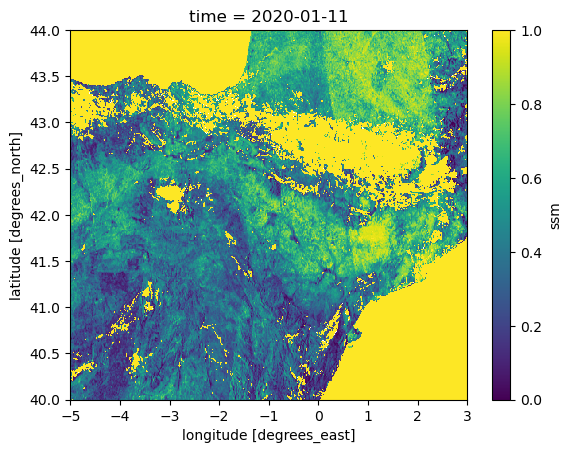

In [50]:
sm_normalized.isel(time=10).plot()

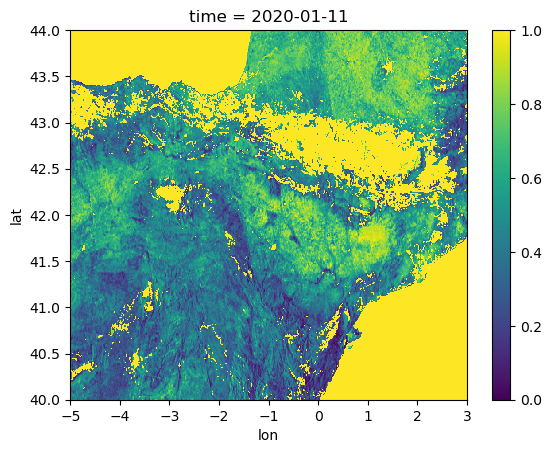

In [51]:
SWI.isel(time=10).plot()

In [52]:
clms_data["SWI"] = SWI.transpose("time", "lat", "lon")
# clms_data["sm_normalized"] = sm_normalized
# clms_data["sm_filled"] = sm_filled

In [54]:
clms_data

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 729, lat: 448, lon: 896)
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    crs      (time) |S1 729B dask.array<chunksize=(729,), meta=np.ndarray>
    ssm      (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    SWI      (time, lat, lon) float64 2GB dask.array<chunksize=(729, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [ ]:
%%time
tds.write_data(clms_data, "soil_moisture_filled.zarr")

In [ ]:
soil_moisture = tds.open_data("soil_moisture_filled.zarr")

In [ ]:
soil_moisture

In [ ]:
soil_moisture["sm_filled"].attrs["long_name"] = "Gap-filled soil moisture"

In [175]:
viewer = Viewer()

INFO:xcube:Loaded service API 'auth'
INFO:xcube:Loaded service API 'styles'
INFO:xcube:Loaded service API 'viewer'
INFO:xcube:Loaded service API 'meta'
INFO:xcube:Loaded service API 'places'
INFO:xcube:Loaded service API 'datasets'
INFO:xcube:Loaded service API 'tiles'
INFO:xcube:Loaded service API 'timeseries'
INFO:xcube:Loaded service API 'statistics'
INFO:xcube:Loaded service API 'volumes'
INFO:xcube:Loaded service API 'expressions'
INFO:xcube:Loaded service API 'ows.coverages'
INFO:xcube:Loaded service API 's3'
INFO:xcube:Loaded service API 'ows.stac'
INFO:xcube:Loaded service API 'compute'
INFO:xcube:Loaded service API 'ows.wmts'
DETAIL:xcube:Added route '/viewer/config/{*path}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/state' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/contributions' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/layout/{contribPoint}/{contribIndex}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/callback' from API 'viewer'

In [64]:
viewer.add_dataset(soil_moisture)

'23da91e0-fc1c-4d83-afd4-01acacb05e2e'

In [65]:
viewer.info()

Server: http://localhost:8002
Viewer: http://localhost:8002/viewer/?serverUrl=http://localhost:8002


In [66]:
viewer.show()

In [67]:
viewer.stop_server()

INFO:xcube:Stopping service...


In [ ]:
### Mask CDS with LandCover and convert the LC to 0-1 bool

In [24]:
keep_classes = [10, 11, 12, 20, 30] # These are classes in LandCover related to Croplands

filtered_lc = lc_cci.lccs_class.where(lc_cci["lccs_class"].isin(keep_classes))
filtered_lc

<xarray.DataArray 'lccs_class' (time: 1, lat: 1440, lon: 2880)> Size: 17MB
dask.array<where, shape=(1, 1440, 2880), dtype=float32, chunksize=(1, 1440, 2880), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 6kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float32 12kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
  * time     (time) datetime64[ns] 8B 2015-07-02T12:00:00
Attributes: (12/16)
    long_name:            Land cover class defined in LCCS
    standard_name:        land_cover_lccs
    flag_values:          [0, 10, 11, 12, 20, 30, 40, 50, 60, 61, 62, 70, 71,...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    valid_min:            1
    valid_max:            220
    ...                   ...
    shape:                [1, 1440, 2880]
    chunk_sizes:          [1, 1440, 2880]
    file_chunk_sizes:     [1440, 2880]
    data_type:            uint8
    dimensions:           ['time', 'lat', 'lon']
    file_dimensions:      ['lat', 'lon']

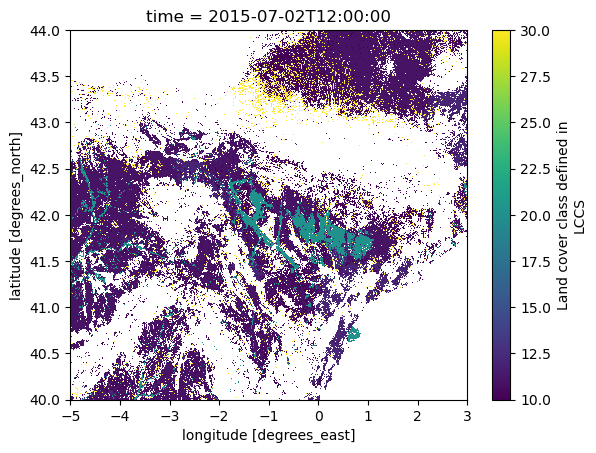

In [73]:
filtered_lc.plot()

In [84]:
total = filtered_lc.size                    
non_nan = int(filtered_lc.count().compute())
nan_count = total - non_nan

In [85]:
total, non_nan, nan_count

(4147200, 1605286, 2541914)

In [25]:
keep_classes_np = np.array(keep_classes, dtype=filtered_lc.dtype)
lc_binary = filtered_lc.isin(keep_classes_np).astype("uint8")
lc_binary

<xarray.DataArray 'lccs_class' (time: 1, lat: 1440, lon: 2880)> Size: 4MB
dask.array<astype, shape=(1, 1440, 2880), dtype=uint8, chunksize=(1, 1440, 2880), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 6kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float32 12kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
  * time     (time) datetime64[ns] 8B 2015-07-02T12:00:00

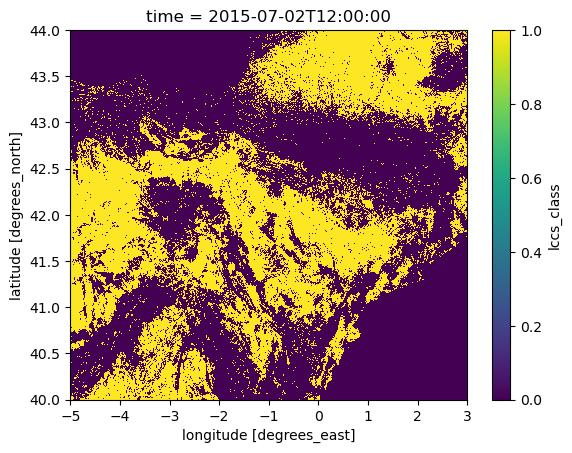

In [87]:
lc_binary.plot()

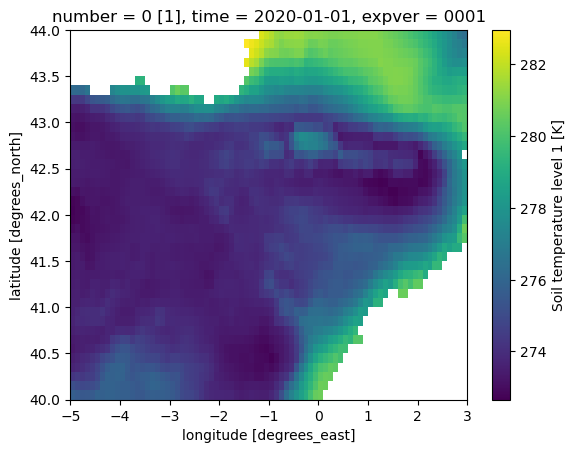

In [95]:
cds_cube.stl1.isel(time=0).plot()

In [42]:
soil_moisture

<xarray.Dataset> Size: 348MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(31,), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [94]:
cds_cube

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 744, lat: 40, lon: 80)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
    expver   (time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    stl1     (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-08T09:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [133]:
stl1_daily = cds_cube["stl1"].resample(time="1D").mean()
pev_daily  = cds_cube["pev"].resample(time="1D").sum()     # different aggregation
tp_daily   = cds_cube["tp"].resample(time="1D").max()
sf_daily   = cds_cube["sf"].resample(time="1D").mean()

cds_cube_daily = xr.merge([stl1_daily, pev_daily, tp_daily, sf_daily])

In [134]:
cds_cube_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 40, lon: 80, time: 31)
Coordinates:
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
    number   int64 8B 0
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1     (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [130]:
cds_cube_daily = cds_cube.resample(time="1D").mean()
cds_cube_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 31, lat: 40, lon: 80)
Coordinates:
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
    number   int64 8B ...
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1     (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-08T09:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [143]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
gm_sm = GridMapping.from_dataset(soil_moisture)
gm_sm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [136]:
gm_cds = GridMapping.from_dataset(cds_cube_daily)
gm_cds

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.1, 0.1)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 80, 40)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (80, 40)
* tile_size: (80, 40)

In [137]:
gm_lc = GridMapping.from_dataset(lc_binary.to_dataset(name="lc_binary"))
gm_lc

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.002777575, 0.0027771)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 2880, 1440)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (2880, 1440)
* tile_size: (2880, 1440)

In [138]:
cds_cube_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 40, lon: 80, time: 31)
Coordinates:
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
    number   int64 8B 0
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1     (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [140]:
cds_in_gm_sm = resample_in_space(cds_cube_daily, target_gm = gm_sm)
cds_in_gm_sm = cds_in_gm_sm.assign_coords(time=cds_cube_daily.time) # this step is needed until resample_in_space is fixed
cds_in_gm_sm

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [141]:
lc_binary.attrs['flag_values'] = [0, 1]
lc_binary.attrs['flag_meanings'] = "no_data croplands_land_cover"

In [143]:
lc_in_gm_sm = resample_in_space(lc_binary.to_dataset(name="lc_binary").isel(time=0), target_gm = gm_sm)
lc_in_gm_sm=lc_in_gm_sm.drop_vars('time')
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

In [235]:
lc_in_gm_sm_mode = resample_in_space(lc_binary.to_dataset(name="lc_binary").isel(time=0), target_gm = gm_sm, agg_methods="mode")
lc_in_gm_sm_mode=lc_in_gm_sm_mode.drop_vars('time')
lc_in_gm_sm_mode

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

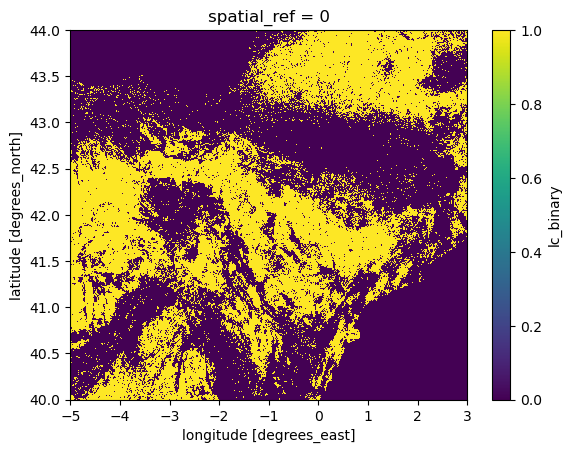

In [237]:
lc_in_gm_sm_mode.lc_binary.plot()

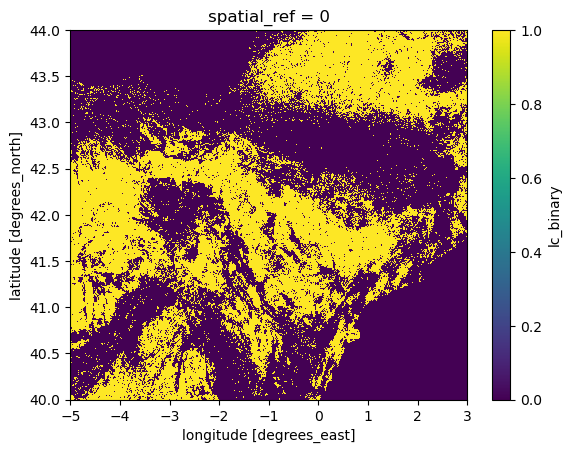

In [238]:
lc_in_gm_sm.lc_binary.plot()

In [144]:
GridMapping.from_dataset(lc_in_gm_sm)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [145]:
GridMapping.from_dataset(cds_in_gm_sm)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [146]:
cds_in_gm_sm

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [147]:
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

In [161]:
cds_masked = cds_in_gm_sm.where(lc_in_gm_sm.lc_binary == 1)
cds_masked

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

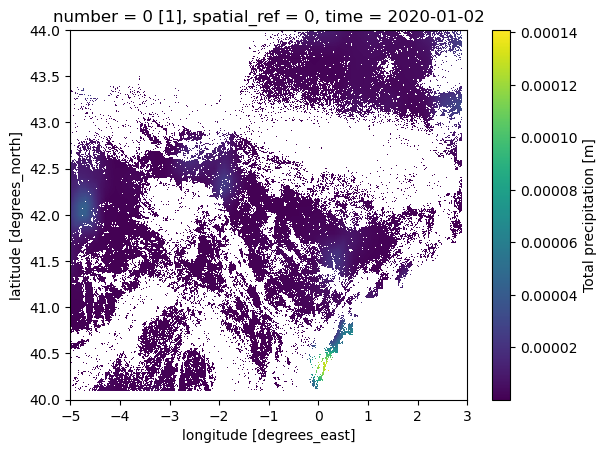

In [162]:
cds_masked.tp.isel(time=1).plot()

In [163]:
def convert_m_to_mm(dataarray, update_long_name=True):
    """
    Convert DataArray values from meters to millimeters.

    Parameters:
    - dataarray: xarray.DataArray, the input data with units in meters.
    - update_long_name: bool, if True, appends '(millimeters)' to long_name attribute.

    Returns:
    - xarray.DataArray with values multiplied by 1000 and updated attributes.
    """
    converted = dataarray * 1000

    converted.attrs = dataarray.attrs.copy()

    converted.attrs['units'] = 'mm'
    converted.attrs['GRIB_units'] = 'mm'
 
    if update_long_name:
        if 'long_name' in converted.attrs:
            converted.attrs['long_name'] = converted.attrs['long_name'] + ' (millimeters)'
        else:
            converted.attrs['long_name'] = 'Potential evaporation (millimeters)'

    return converted


In [164]:
cds_masked["pev"] =  convert_m_to_mm(cds_masked["pev"])
cds_masked["tp"] =  convert_m_to_mm(cds_masked["tp"])
cds_masked

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

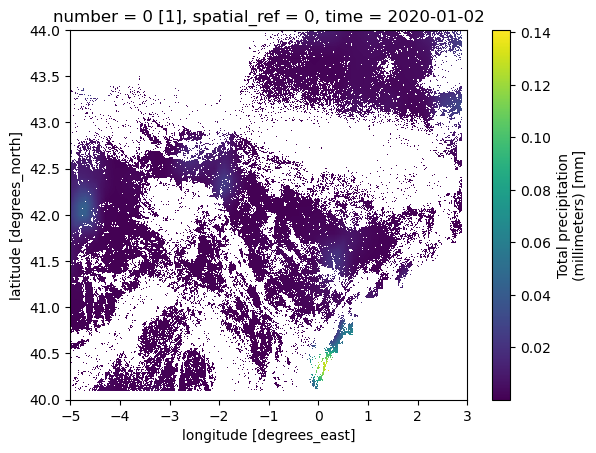

In [165]:
cds_masked.tp.isel(time=1).plot()

In [166]:
soil_moisture

<xarray.Dataset> Size: 348MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(31,), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [167]:
cds_masked

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

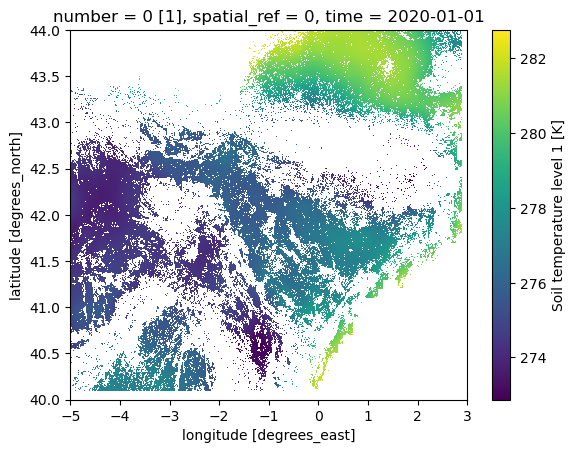

In [187]:
cds_masked.stl1.isel(time=0).plot()

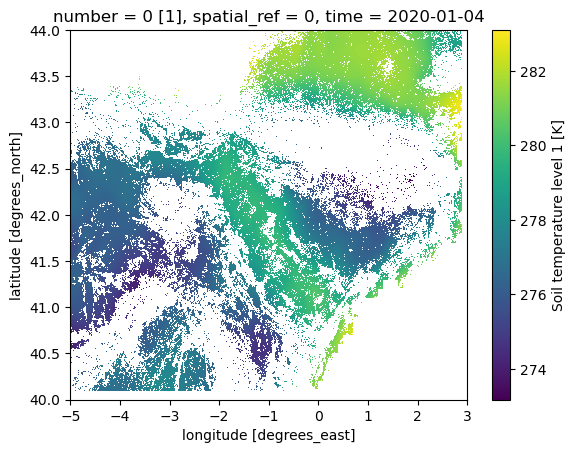

In [188]:
cds_masked.stl1.isel(time=3).plot()

In [168]:
# lc_mask = lc_mask_expanded.to_dataset(name="lc_mask_expanded")
# lc_mask
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

In [179]:
ds_combined = xr.merge([soil_moisture, cds_masked, lc_in_gm_sm])
ds_combined

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
    number         int64 8B 0
    spatial_ref    int64 8B 0
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(31,), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [180]:
chunked_ds = chunk_dataset(ds_combined, chunk_sizes={"time":1, "lat":448, "lon":896}, format_name="zarr")

In [181]:
chunked_ds

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
    number         int64 8B 0
    spatial_ref    int64 8B 0
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(1,), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [182]:
fsd.write_data(chunked_ds, "irrigation_input.zarr")

'irrigation_input.zarr'

In [228]:
irrigation_input=fsd.open_data("irrigation_input.zarr")
irrigation_input

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(1,), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

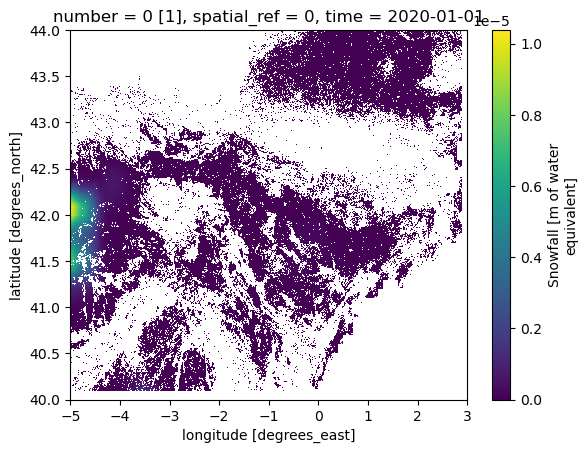

In [197]:
irrigation_input.sf.isel(time=0).plot()

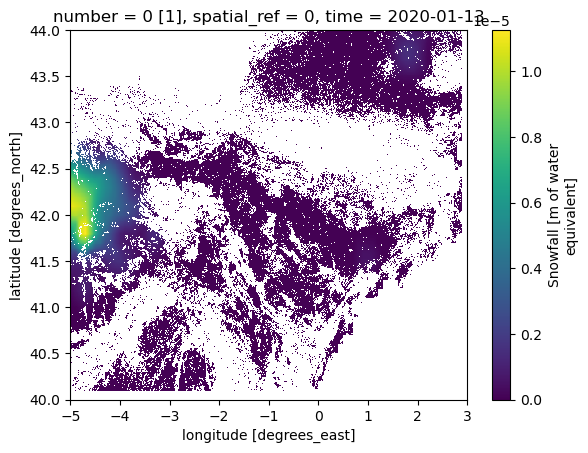

In [198]:
irrigation_input.sf.isel(time=12).plot()

In [184]:
from xcube.webapi.viewer import Viewer
viewer = Viewer()

INFO:xcube:Loaded service API 'auth'
INFO:xcube:Loaded service API 'styles'
INFO:xcube:Loaded service API 'viewer'
INFO:xcube:Loaded service API 'meta'
INFO:xcube:Loaded service API 'places'
INFO:xcube:Loaded service API 'datasets'
INFO:xcube:Loaded service API 'tiles'
INFO:xcube:Loaded service API 'timeseries'
INFO:xcube:Loaded service API 'statistics'
INFO:xcube:Loaded service API 'volumes'
INFO:xcube:Loaded service API 'expressions'
INFO:xcube:Loaded service API 'ows.coverages'
INFO:xcube:Loaded service API 's3'
INFO:xcube:Loaded service API 'ows.stac'
INFO:xcube:Loaded service API 'compute'
INFO:xcube:Loaded service API 'ows.wmts'
DETAIL:xcube:Added route '/viewer/config/{*path}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/state' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/contributions' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/layout/{contribPoint}/{contribIndex}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/callback' from API 'viewer'

In [185]:
viewer.add_dataset(irrigation_input)

'4f1b1c36-0fc8-477b-a5b6-b452f974fafd'

In [223]:
viewer.info()

Server: http://localhost:8002
Viewer: http://localhost:8002/viewer/?serverUrl=http://localhost:8002


In [186]:
viewer.show()

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = masked_lc["lccs_class"].isel(time=0)
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()

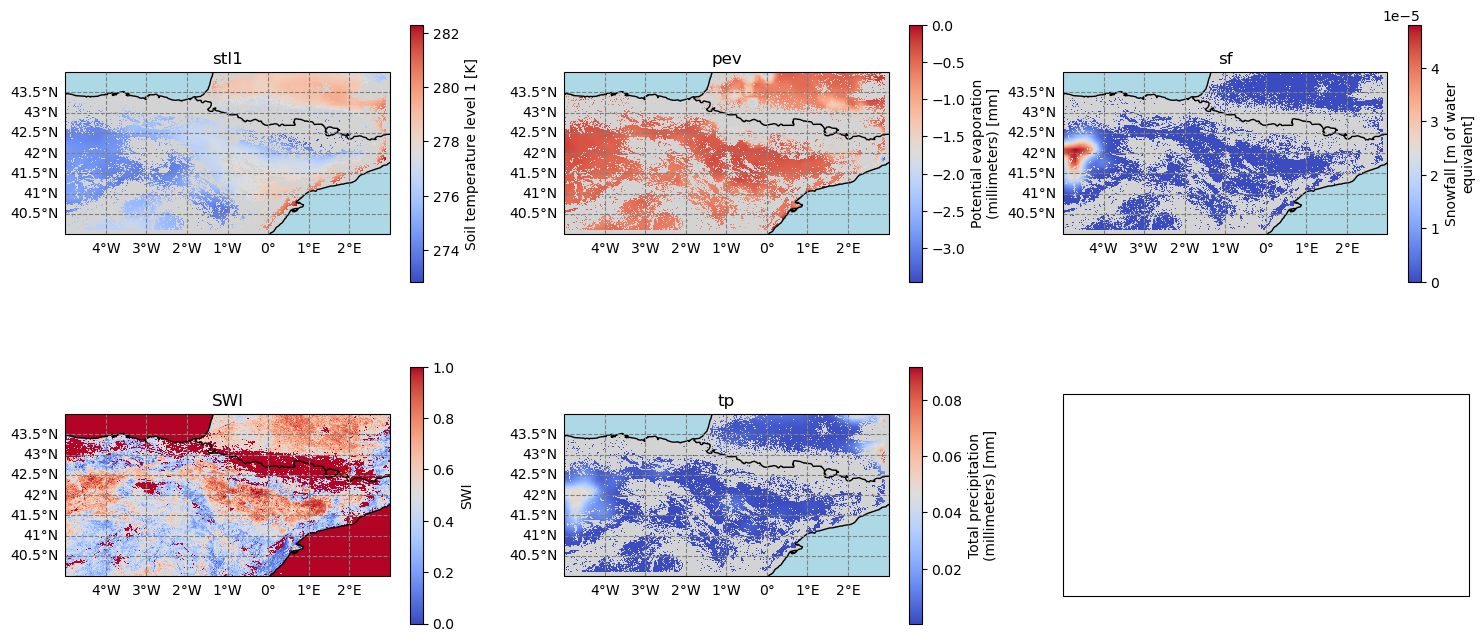

In [210]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = irrigation_input.isel(time=5)
vars_to_plot = ["stl1", "pev", "sf", "SWI", "tp"]

proj = ccrs.PlateCarree()
n_vars = len(vars_to_plot)
n_cols = 3
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    subplot_kw={"projection": proj}
)

for ax, var in zip(axes.flat, vars_to_plot):
    da = ds[var]
    da.plot(ax=ax, transform=proj, cmap="coolwarm", cbar_kwargs={"shrink": 0.6})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.set_title(var)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False

# for ax in axes.flat[n_vars:]:
#     ax.set_visible(False)

plt.tight_layout()
plt.show()


In [219]:
irrigation_input

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(1,), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [221]:
irrigation_input.tp.sum(dim="time", skipna=True).compute()

<xarray.DataArray 'tp' (lat: 448, lon: 896)> Size: 2MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(448, 896), dtype=float32)
Coordinates:
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number       int64 8B 0
    spatial_ref  int64 8B 0

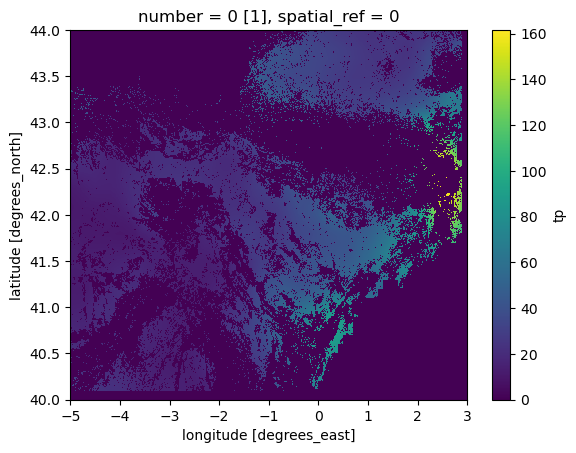

In [222]:
irrigation_input.tp.sum(dim="time", skipna=True).compute().plot()

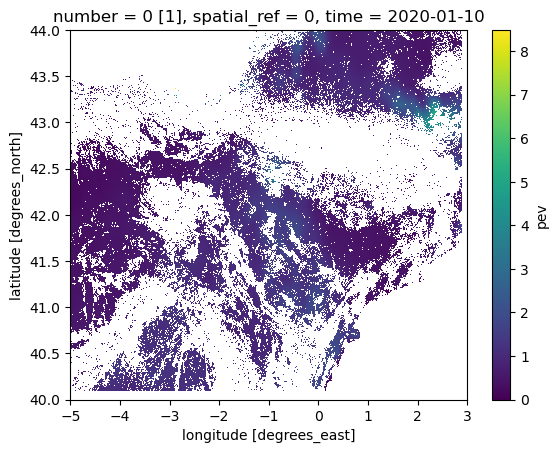

In [229]:
irrigation_input["pev"] = irrigation_input["pev"] * -1
irrigation_input.pev.isel(time=9).plot()

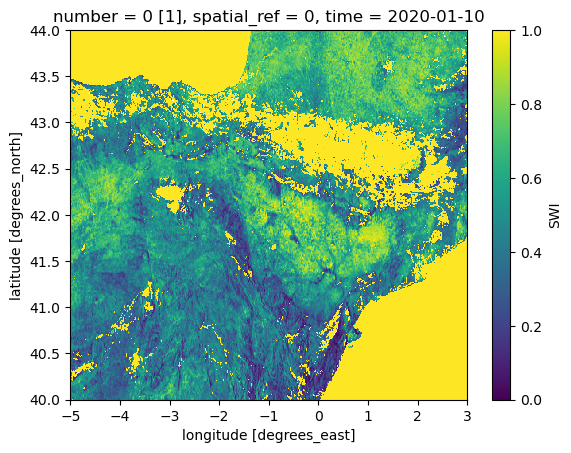

In [230]:
irrigation_input.SWI.isel(time=9).plot()

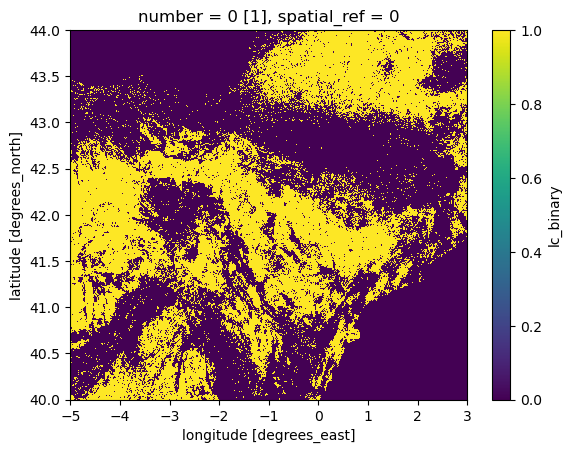

In [232]:
irrigation_input.lc_binary.plot()

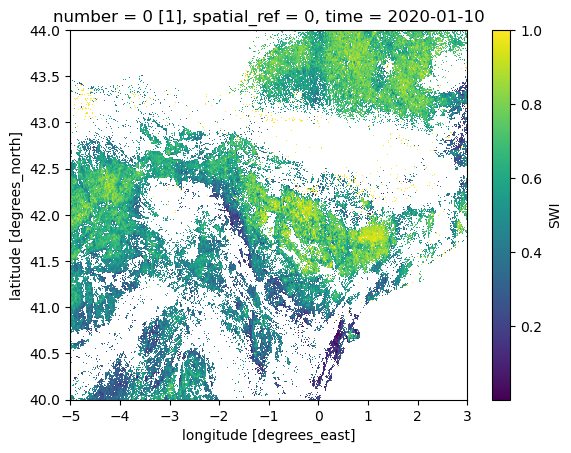

In [233]:
irrigation_input["SWI"] = irrigation_input["SWI"].where(irrigation_input.lc_binary == 1)
irrigation_input.SWI.isel(time=9).plot()

In [ ]:
irrigation_input

In [234]:
fsd.write_data(irrigation_input, "irrigation_input_final.zarr")

'irrigation_input_final.zarr'

In [227]:
irrigation_input.lc_binary

<xarray.DataArray 'lc_binary' (lat: 448, lon: 896)> Size: 401kB
dask.array<open_dataset-lc_binary, shape=(448, 896), dtype=uint8, chunksize=(448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number       int64 8B ...
    spatial_ref  int64 8B ...
Attributes:
    flag_meanings:  no_data croplands_land_cover
    flag_values:    [0, 1]
    grid_mapping:   spatial_ref

In [225]:
irrigation_input

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(1,), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

# TODO:
- Change the sign for pev to positive (mulitply by -1)
- SWI - filter again using LC

In [205]:
GridMapping.from_dataset(irrigation_input)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [207]:
0.008928575*111.32

0.9939289689999998